# Module 1: Attention Basics

## Learning Objectives

- Understand the motivation behind attention
- Know what problems attention solves
- Learn the basic attention computation
- See real examples of attention in action

**Duration**: ~15 minutes

## 1. The Problem: Long-Range Dependencies

### RNNs and Vanishing Gradients

Consider translating a sentence:

```
Source: "I grew up in France ... ... ... ... and I speak French"
Target: "J'ai grandie en France ... ... ... ... et je parle Francais"
```

**The Problem**:
- RNNs process sequentially: word by word
- Information from early words gets diluted
- By the time we reach the end, we've "forgotten" about France
- Gradients vanish during backpropagation through time

**The Solution**:
- Attention allows direct connections between words
- "French" can directly attend to "France"
- No gradient path needed to travel through intermediate words

### Visual Example

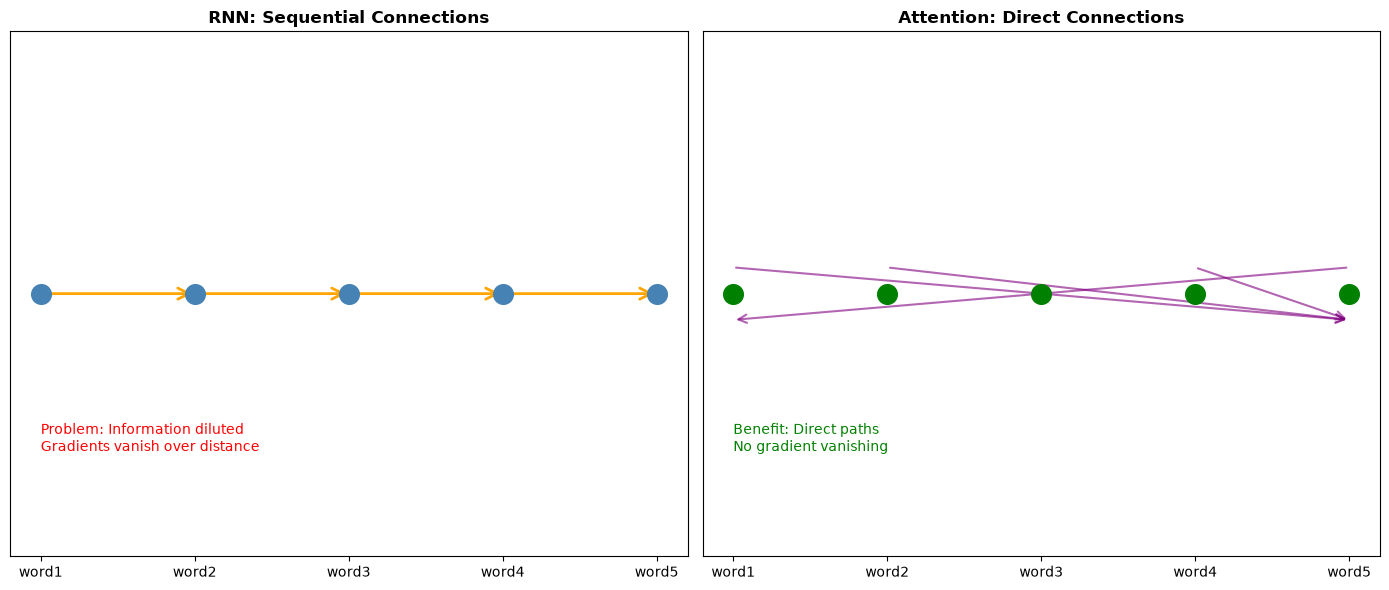

✓ RNN has O(n) path length from word1 to word5
✓ Attention has O(1) direct connections

This is why attention is better for long sequences!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

# Create comparison: RNN vs Attention
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RNN: Sequential connections
ax = axes[0]
positions = np.arange(5)
ax.scatter(positions, np.ones(5), s=200, c='steelblue', zorder=3)
ax.set_xticks(positions)
ax.set_xticklabels(['word1', 'word2', 'word3', 'word4', 'word5'])
ax.set_ylim(0.5, 1.5)
ax.set_title('RNN: Sequential Connections', fontsize=12, weight='bold')

# Draw sequential connections
for i in range(len(positions) - 1):
    arrow = FancyArrowPatch(
        (positions[i], 1), (positions[i+1], 1),
        arrowstyle='->', mutation_scale=20, lw=2, color='orange'
    )
    ax.add_patch(arrow)

ax.text(0, 0.7, 'Problem: Information diluted\nGradients vanish over distance', 
        fontsize=10, color='red')
ax.set_ylabel('')
ax.set_yticks([])

# Attention: All-to-all connections
ax = axes[1]
ax.scatter(positions, np.ones(5), s=200, c='green', zorder=3)
ax.set_xticks(positions)
ax.set_xticklabels(['word1', 'word2', 'word3', 'word4', 'word5'])
ax.set_ylim(0.5, 1.5)
ax.set_title('Attention: Direct Connections', fontsize=12, weight='bold')

# Draw some attention connections
important_connections = [(0, 4), (1, 4), (3, 4), (4, 0)]
for src, tgt in important_connections:
    arrow = FancyArrowPatch(
        (positions[src], 1.05), (positions[tgt], 0.95),
        arrowstyle='->', mutation_scale=15, lw=1.5, color='purple', alpha=0.6
    )
    ax.add_patch(arrow)

ax.text(0, 0.7, 'Benefit: Direct paths\nNo gradient vanishing', 
        fontsize=10, color='green')
ax.set_ylabel('')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('rnn_vs_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ RNN has O(n) path length from word1 to word5")
print("✓ Attention has O(1) direct connections")
print("\nThis is why attention is better for long sequences!")

## 2. What is Attention?

Attention is a **weighted average**:

```
Attention = sum of (weight_i * value_i) for all i
```

Where:
- `weight_i` depends on how "relevant" position i is
- Weights sum to 1 (softmax normalization)
- We focus more on relevant positions

### Real-World Analogy

Imagine you're reading a book and need to understand a word:

```
Sentence: "The bank approved the loan"
          ↑                    ↑
       Query              Values

Attention weights for "loan":
- "The"     : 0.05  (not relevant)
- "bank"    : 0.7   (highly relevant - who approved?)
- "approved": 0.2   (somewhat relevant - the action)
- "the"     : 0.03  (not relevant)
- "loan"    : 0.02  (self-reference)

Result: Focus mostly on "bank", some on "approved"
```

## 3. Simple Attention Example

Let's implement attention from scratch

In [2]:
import torch
import torch.nn.functional as F

# Simple attention mechanism
def simple_attention(query, keys, values):
    """
    Compute attention weights and output.
    
    Args:
        query: (1, d) - What we're looking for
        keys: (n, d) - What each position has
        values: (n, d) - What each position contains
    
    Returns:
        output: Weighted sum of values
        weights: Attention weights
    """
    # Step 1: Compute similarity between query and each key
    scores = torch.matmul(query, keys.T)  # (1, n)
    
    # Step 2: Normalize with softmax
    weights = F.softmax(scores, dim=1)  # (1, n)
    
    # Step 3: Apply weights to values
    output = torch.matmul(weights, values)  # (1, d)
    
    return output, weights

# Example: Understanding a word in context
print("="*50)
print("Example: Processing the word 'bank'")
print("="*50)

# Vocabulary
vocab = ['The', 'bank', 'approved', 'the', 'loan']
n_words = len(vocab)
d = 4  # embedding dimension

# Create embeddings (random for illustration)
torch.manual_seed(42)
embeddings = torch.randn(n_words, d)

# The query is for the word 'approved' (index 2)
query = embeddings[2:3]  # (1, 4)
keys = embeddings  # (5, 4)
values = embeddings  # (5, 4)

# Compute attention
output, weights = simple_attention(query, keys, values)

print("\nWord we're processing: 'approved'")
print("\nAttention weights for each word:")
print("-" * 40)
for word, weight in zip(vocab, weights[0].detach().numpy()):
    bar_length = int(weight * 50)
    bar = "█" * bar_length
    print(f"{word:12} {weight:.3f}  {bar}")

print(f"\nOutput vector shape: {output.shape}")
print(f"Output vector: {output[0].detach().numpy()}")

Example: Processing the word 'bank'

Word we're processing: 'approved'

Attention weights for each word:
----------------------------------------
The          0.055  ██
bank         0.073  ███
approved     0.489  ████████████████████████
the          0.248  ████████████
loan         0.135  ██████

Output vector shape: torch.Size([1, 4])
Output vector: [ 0.12480026 -0.2184098  -0.08689339  0.25467712]


## 4. Attention in Machine Translation

The original motivation for attention

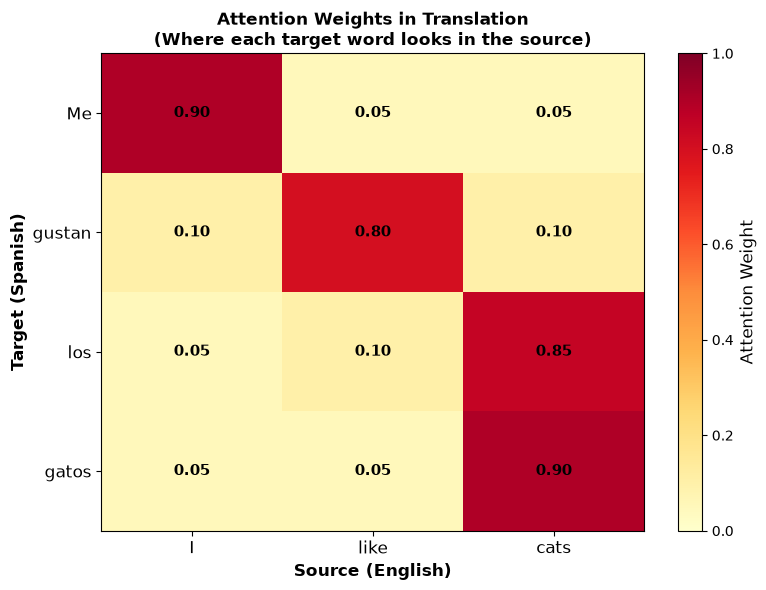


Attention Interpretation:
When translating 'Me'
  → Focus on 'I' in source

When translating 'gustan'
  → Focus on 'like' in source

When translating 'los'
  → Focus on 'cats' in source

When translating 'gatos'
  → Focus on 'cats' in source



In [3]:
# Machine translation example
# Each target word attends to source words

source = ['I', 'like', 'cats']
target = ['Me', 'gustan', 'los', 'gatos']

# Alignments (ground truth)
alignments = {
    'Me': 'I',           # 1st target attends to 1st source
    'gustan': 'like',    # 2nd target attends to 2nd source
    'los': 'cats',       # 3rd target attends to 3rd source
    'gatos': 'cats',     # 4th target attends to 3rd source
}

# Simulate attention matrix
# Each row = target word, each column = source word
attention_matrix = np.array([
    [0.9, 0.05, 0.05],   # 'Me' → 'I'
    [0.1, 0.8, 0.1],     # 'gustan' → 'like'
    [0.05, 0.1, 0.85],   # 'los' → 'cats'
    [0.05, 0.05, 0.9],   # 'gatos' → 'cats'
])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(attention_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(source)))
ax.set_yticks(range(len(target)))
ax.set_xticklabels(source, fontsize=12)
ax.set_yticklabels(target, fontsize=12)

ax.set_xlabel('Source (English)', fontsize=12, weight='bold')
ax.set_ylabel('Target (Spanish)', fontsize=12, weight='bold')
ax.set_title('Attention Weights in Translation\n(Where each target word looks in the source)', 
             fontsize=12, weight='bold')

# Add text annotations
for i in range(len(target)):
    for j in range(len(source)):
        text = ax.text(j, i, f'{attention_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=11, weight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Attention Weight', fontsize=12)

plt.tight_layout()
plt.savefig('translation_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAttention Interpretation:")
print("=" * 50)
for target_word, source_word in alignments.items():
    print(f"When translating '{target_word}'")
    print(f"  → Focus on '{source_word}' in source")
    print()

## 5. Key Takeaways

### ✅ What We Learned

1. **Problem**: RNNs suffer from vanishing gradients over long distances
2. **Solution**: Attention creates direct connections between words
3. **Mechanism**: Weighted average of values based on query-key similarity
4. **Benefits**:
   - Handles long-range dependencies
   - More interpretable (we can see attention weights)
   - Parallelizable (no recurrence)
   - Flexible for variable-length sequences

### 🎯 Next Steps

1. **Notebook 2**: Scaled Dot-Product Attention (the actual formula)
2. **Notebook 3**: Multi-Head Attention (multiple attention heads)
3. **Notebook 4**: Full Transformer Architecture

### 📝 Summary

Attention is essentially asking:
> "Given my current query, which parts of the input are most relevant?"

And it answers by computing a weighted average, focusing on the relevant parts.